# iPLA vs Simoa NfL: Method Comparison

Compares NfL concentrations measured by the NfL-iPLA assay against Simoa (Quanterix HD-X) across three clinical cohorts. All analyses use MIQE-compliant raw qPCR exports (`data_submission/`) and Simoa source files.

See `Simoa_Comparison.ipynb` for the original exploratory analysis.

---

In [1]:
# ── Environment setup ─────────────────────────────────────────────────────
# ProxiPal is the project's custom analysis library (ProxiPal.py in repo root).

import sys
from pathlib import Path

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *
# ProxiPal also imports pandas, numpy, scipy, matplotlib — these are
# available after this line without separate import statements.
# See: https://github.com/jeffsmith8/NfL-iPLA-paper


OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-07-06 16:31:20
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\iPLAvsSimoa
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\smith.j\OneDriv

## Data loading

| Cohort | Matrix | iPLA source | Simoa source |
|---|---|---|---|
| RMH Li-Hep | Li-Hep plasma | `PLA_RMH_LH_raw.csv` | `simoa_RMH.csv` |
| Beyond EDTA | EDTA plasma | `PLA_Beyond_EDTA_raw.csv` | `simoa_BY.csv` |
| MiND EDTA | EDTA plasma | `PLA_MiND_EDTA_raw.csv` | `simoa_Olink_PLA_MiND.csv` |

PLA files are MIQE-compliant raw reaction exports (`data_submission/`). Simoa files are instrument exports with standardised column names applied below.


In [2]:
# ── iPLA raw data exports ────────────────────────────────
pla_rmh   = pd.read_csv('PLA_RMH_LH_raw.csv')
pla_by    = pd.read_csv('PLA_Beyond_EDTA_raw.csv')
pla_mind  = pd.read_csv('PLA_MiND_EDTA_raw.csv')

# ── Simoa data ────────────────────────────────────────────────────────
simoa_rmh  = pd.read_csv('simoa_RMH.csv')
simoa_by   = pd.read_csv('simoa_BY.csv')
mind_olink = pd.read_csv('simoa_Olink_PLA_MiND.csv')   # contains MiND Simoa + Olink + PLA means

# ── Standardise column names on Simoa files ─────────
simoa_rmh.columns  = ['sample_id', 'Simoa NfL pg/ml', 'Simoa GFAP pg/ml', 'PLA NfL pg/ml', 'retested (PLA)']
simoa_by.columns   = ['sample_id', 'Simoa NfL pg/ml', 'Simoa GFAP pg/ml', 'PLA NfL pg/ml']

# ── Drop non-numeric Simoa NfL rows (e.g. "<LOQ" strings) in RMH ─────────────
simoa_rmh = simoa_rmh[pd.to_numeric(simoa_rmh['Simoa NfL pg/ml'], errors='coerce').notna()].reset_index(drop=True)
simoa_rmh['Simoa NfL pg/ml'] = pd.to_numeric(simoa_rmh['Simoa NfL pg/ml'])
simoa_rmh['PLA NfL pg/ml']   = pd.to_numeric(simoa_rmh['PLA NfL pg/ml'])

# BY0005 NULF851894: manifest reconciliation revealed tube ID mismatch between Simoa and iPLA — exclude
simoa_by = simoa_by[simoa_by['sample_id'] != 'BY0005 NULF851894'].reset_index(drop=True)

# ── Drop MiND rows without Simoa value ───────────────────────────────────────
mind_olink_f = mind_olink[mind_olink['simoa_pg/ml'].notna()].reset_index(drop=True)

# ── Derive paired plot-ready means ─────────────────────
# RMH: unified mean (SLR where available, fallback to usr_mean)
# usr_mean is calculated in in excel (not programmtically). Sometimes necessary for 
# instrument data not in the current data pipeline (i.e. Bio-Rad)
pla_rmh['mean_pg/L_unified'] = (pla_rmh['SLR; log10(x); exc_std0; ct; mean_ng/L']
                                .fillna(pla_rmh['usr_mean_ng/L']))

# Beyond: SLR mean only (all 2025 experiments are ProxiPal-compatible)
# MiND: SLR mean only

print("RMH MIQE rows   :", len(pla_rmh))
print("Beyond MIQE rows:", len(pla_by))
print("MiND MIQE rows  :", len(pla_mind))
print()
print("RMH Simoa rows  :", len(simoa_rmh))
print("Beyond Simoa rows:", len(simoa_by))
print("MiND Olink rows :", len(mind_olink_f))

RMH MIQE rows   : 500
Beyond MIQE rows: 140
MiND MIQE rows  : 84

RMH Simoa rows  : 247
Beyond Simoa rows: 70
MiND Olink rows : 42


## RMH Li-Hep plasma

Samples collected by RMH Pathology, split between Simoa (Gothenburg) and iPLA (WEHI). Matrix: Li-Hep plasma.

The MIQE export is deduplicated to one row per `(sample_id, rep_id, mean, filepath)` before merging with Simoa values. The unified mean column uses the ProxiPal SLR estimate where available, falling back to `usr_mean_ng/L` for e103 Bio-Rad CFX rows (ProxiPal-incompatible instrument).


In [3]:
# ── RMH Li-Hep: build paired dataframe from MIQE export ─────────────────────

# Deduplicate to one row per (sample_id, rep_id, mean, filepath)
rmh_means = pla_rmh.drop_duplicates(
    subset=['sample_id', 'rep_id', 'mean_pg/L_unified', 'filepath_csv'],
    keep='first'
).copy()

# Merge Simoa values onto deduplicated PLA means
rmh_paired = simoa_rmh[['sample_id', 'Simoa NfL pg/ml']].merge(
    rmh_means[['sample_id', 'mean_pg/L_unified']],
    on='sample_id'
).rename(columns={'mean_pg/L_unified': 'PLA NfL pg/ml'})

## Method comparison: Passing-Bablok regression

Passing-Bablok (PB) regression was performed on the full concentration range 
for each cohort. Spearman R was calculated on untransformed data. All reported 
regression parameters (slope, intercept, Spearman R) reflect the full-range 
analysis.

Figure panels in the main body are displayed at a zoomed axis range reflecting 
the concentration distribution of each cohort: RMH Li-Hep plasma samples are 
shown up to 200 pg/mL, and Beyond/MiND EDTA plasma samples are shown up to 
25 pg/mL, consistent with the younger age profile of the MiND cohort and the 
consequently lower NfL concentrations observed. Full-range plots for both 
cohorts are provided in the supplementary figures.

### Figure style

All figures use 88 mm single-column width (Nature Communications), 6 pt Helvetica, and the Okabe-Ito colour palette. Matrix type is encoded by colour and marker: Li-Hep plasma = blue triangle (`^`), EDTA plasma = vermillion square (`s`).


In [4]:
# ── Global rcParams ───────────────────────────────────────────────────────────
plt.rcParams['font.family']        = 'sans-serif'
plt.rcParams['font.sans-serif']    = ['Helvetica', 'Arial']
plt.rcParams['font.size']          = 6
plt.rcParams['axes.titlesize']     = 6
plt.rcParams['axes.labelsize']     = 6
plt.rcParams['xtick.labelsize']    = 6
plt.rcParams['ytick.labelsize']    = 6
plt.rcParams['legend.fontsize']    = 6
plt.rcParams['axes.linewidth']     = 0.6
plt.rcParams['scatter.edgecolors'] = 'none'

# ── Okabe-Ito palette ─────────────────────────────────────────────────────────
okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}

matrix_colours = {
    'EDTA plasma':   okabe_ito['vermillion'],
    'Li-Hep plasma': okabe_ito['blue'],
}


RMH Li-Hep Samples, full range  
Use this one in supplementary (full visual range)

In [5]:
# ── Passing-Bablok ───────────────────────────────────────────────────────────
beta, alpha = passing_bablok(rmh_paired['Simoa NfL pg/ml'], rmh_paired['PLA NfL pg/ml'])


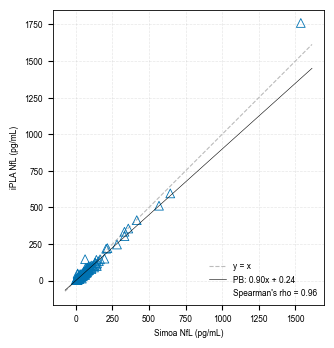

In [6]:
# ── RMH Li-Hep: Passing-Bablok plot ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

ax.scatter(
    rmh_paired['Simoa NfL pg/ml'], rmh_paired['PLA NfL pg/ml'],
    s=40, marker='^',
    facecolors='none', edgecolors=matrix_colours['Li-Hep plasma'],
    linewidths=0.6, zorder=3
)

ax.set_xlabel('Simoa NfL (pg/mL)')
ax.set_ylabel('iPLA NfL (pg/mL)')
ax.set_aspect('equal', adjustable='box')

x_range = np.linspace(*ax.get_xlim(), 200)
ax.plot(x_range, x_range,
        color='#BBBBBB', linewidth=0.8, ls='--', zorder=1)
ax.plot(x_range, beta[0] * x_range + alpha[0],
        color=okabe_ito['black'], linewidth=0.4, zorder=4)

Rs, _ = spearmanr(rmh_paired['Simoa NfL pg/ml'], rmh_paired['PLA NfL pg/ml'],
                  nan_policy='omit')

stats_handles = [
    Line2D([0], [0], color='#BBBBBB', ls='--', linewidth=0.8, label='y = x'),
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.4,
           label=f'PB: {beta[0]:.2f}x + {alpha[0]:.2f}'),
    Line2D([0], [0], color='none', label=f"Spearman's rho = {Rs:.2f}"),
]
ax.legend(handles=stats_handles, frameon=False, loc='lower right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('SimoavPLA_RMH_LH_full.svg', dpi=300, bbox_inches='tight')
plt.show()

Use this one in main (best visual distribution)

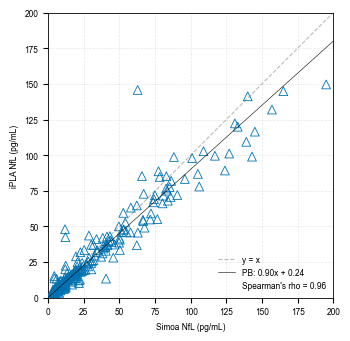

In [7]:
# ── RMH Li-Hep: Passing-Bablok plot (main figure, axis limited to 200 pg/mL) ──
# PB regression fitted on full range — axis range reflects cohort distribution

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

ax.scatter(
    rmh_paired['Simoa NfL pg/ml'], rmh_paired['PLA NfL pg/ml'],
    s=40, marker='^',
    facecolors='none', edgecolors=matrix_colours['Li-Hep plasma'],
    linewidths=0.6, zorder=3
)

ax.set_xlabel('Simoa NfL (pg/mL)')
ax.set_ylabel('iPLA NfL (pg/mL)')
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)
ax.set_aspect('equal', adjustable='box')

x_range = np.linspace(0, 200, 200)
ax.plot(x_range, x_range,
        color='#BBBBBB', linewidth=0.8, ls='--', zorder=1)
ax.plot(x_range, beta[0] * x_range + alpha[0],
        color=okabe_ito['black'], linewidth=0.4, zorder=4)

Rs, _ = spearmanr(rmh_paired['Simoa NfL pg/ml'], rmh_paired['PLA NfL pg/ml'],
                  nan_policy='omit')

stats_handles = [
    Line2D([0], [0], color='#BBBBBB', ls='--', linewidth=0.8, label='y = x'),
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.4,
           label=f'PB: {beta[0]:.2f}x + {alpha[0]:.2f}'),
    Line2D([0], [0], color='none', label=f"Spearman's rho = {Rs:.2f}"),
]
ax.legend(handles=stats_handles, frameon=False, loc='lower right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('SimoavPLA_RMH_LH_main.svg', dpi=300, bbox_inches='tight')
plt.show()

RMH Li-Hep Samples, <200pg/ml  
Separate PB testing for bias at low concentrations

RMH <200 pg/mL N = 237


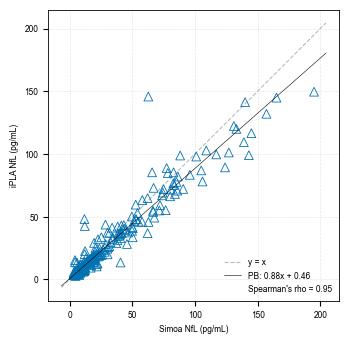

In [8]:
# ── RMH Li-Hep <200 pg/mL: Passing-Bablok ────────────────────────────────────

rmh_paired_200 = rmh_paired[rmh_paired['Simoa NfL pg/ml'] < 200].reset_index(drop=True)
print(f"RMH <200 pg/mL N = {len(rmh_paired_200)}")

beta_200, alpha_200 = passing_bablok(rmh_paired_200['Simoa NfL pg/ml'], rmh_paired_200['PLA NfL pg/ml'])

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

ax.scatter(
    rmh_paired_200['Simoa NfL pg/ml'], rmh_paired_200['PLA NfL pg/ml'],
    s=40, marker='^',
    facecolors='none', edgecolors=matrix_colours['Li-Hep plasma'],
    linewidths=0.6, zorder=3
)

ax.set_xlabel('Simoa NfL (pg/mL)')
ax.set_ylabel('iPLA NfL (pg/mL)')
ax.set_aspect('equal', adjustable='box')

x_range = np.linspace(*ax.get_xlim(), 200)
ax.plot(x_range, x_range,
        color='#BBBBBB', linewidth=0.8, ls='--', zorder=1)
ax.plot(x_range, beta_200[0] * x_range + alpha_200[0],
        color=okabe_ito['black'], linewidth=0.4, zorder=4)

Rs, _ = spearmanr(rmh_paired_200['Simoa NfL pg/ml'], rmh_paired_200['PLA NfL pg/ml'],
                  nan_policy='omit')

stats_handles = [
    Line2D([0], [0], color='#BBBBBB', ls='--', linewidth=0.8, label='y = x'),
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.4,
           label=f'PB: {beta_200[0]:.2f}x + {alpha_200[0]:.2f}'),
    Line2D([0], [0], color='none', label=f"Spearman's rho = {Rs:.2f}"),
]
ax.legend(handles=stats_handles, frameon=False, loc='lower right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('SimoavPLA_RMH_LH_200.svg', dpi=300, bbox_inches='tight')
plt.show()

RMH Li-Hep Samples, <25pg/ml  
Separate PB testing for bias at low concentrations

RMH <25 pg/mL N = 143


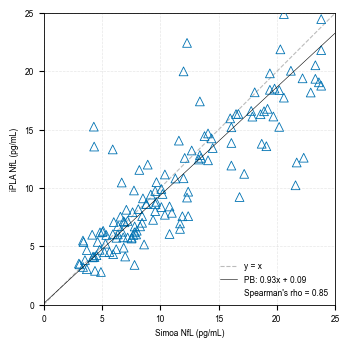

In [9]:
# ── RMH Li-Hep <25 pg/mL: Passing-Bablok ─────────────────────────────────────

rmh_paired_25 = rmh_paired[rmh_paired['Simoa NfL pg/ml'] < 25].reset_index(drop=True)
print(f"RMH <25 pg/mL N = {len(rmh_paired_25)}")

beta_rmh_25, alpha_rmh_25 = passing_bablok(rmh_paired_25['Simoa NfL pg/ml'], rmh_paired_25['PLA NfL pg/ml'])

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

ax.scatter(
    rmh_paired_25['Simoa NfL pg/ml'], rmh_paired_25['PLA NfL pg/ml'],
    s=40, marker='^',
    facecolors='none', edgecolors=matrix_colours['Li-Hep plasma'],
    linewidths=0.6, zorder=3
)

ax.set_xlabel('Simoa NfL (pg/mL)')
ax.set_ylabel('iPLA NfL (pg/mL)')
ax.set_xlim(0, 25)
ax.set_ylim(0, 25)
ax.set_aspect('equal', adjustable='box')

x_range = np.linspace(0, 25, 200)
ax.plot(x_range, x_range,
        color='#BBBBBB', linewidth=0.8, ls='--', zorder=1)
ax.plot(x_range, beta_rmh_25[0] * x_range + alpha_rmh_25[0],
        color=okabe_ito['black'], linewidth=0.4, zorder=4)

Rs, _ = spearmanr(rmh_paired_25['Simoa NfL pg/ml'], rmh_paired_25['PLA NfL pg/ml'],
                  nan_policy='omit')

stats_handles = [
    Line2D([0], [0], color='#BBBBBB', ls='--', linewidth=0.8, label='y = x'),
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.4,
           label=f'PB: {beta_rmh_25[0]:.2f}x + {alpha_rmh_25[0]:.2f}'),
    Line2D([0], [0], color='none', label=f"Spearman's rho = {Rs:.2f}"),
]
ax.legend(handles=stats_handles, frameon=False, loc='lower right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('SimoavPLA_RMH_LH_25.svg', dpi=300, bbox_inches='tight')
plt.show()

## Beyond + MiND EDTA plasma

Two EDTA plasma cohorts combined for method comparison:

- **Beyond**: community-based cohort, iPLA data from 2025 experiments (e120–e122)
- **MiND**: memory clinic cohort, younger patients with lower baseline NfL

Both cohorts use the same EDTA matrix and are plotted with a single marker type. The concentration distribution is dominated by values <25 pg/mL, reflecting the younger age profile of the MiND cohort. Full-range plots are provided as supplementary figures alongside the zoomed main figures.


In [10]:
# ── Beyond + MiND EDTA: build paired dataframes ───────────────────────────────

# Beyond: deduplicate and merge
by_means = pla_by.drop_duplicates(
    subset=['sample_id', 'rep_id', 'SLR; log10(x); exc_std0; ct; mean_ng/L', 'filepath_csv'],
    keep='first'
).copy()

simoa_by_split = simoa_by.copy()
simoa_by_split['sample_id'] = simoa_by_split['sample_id'].str.split(' ').str[0]

by_paired = simoa_by_split[['sample_id', 'Simoa NfL pg/ml']].merge(
    by_means[['sample_id', 'SLR; log10(x); exc_std0; ct; mean_ng/L']],
    on='sample_id'
).rename(columns={'SLR; log10(x); exc_std0; ct; mean_ng/L': 'PLA NfL pg/ml'})

print(f"Beyond paired N = {len(by_paired)}")

# MiND: deduplicate and merge
mind_means = pla_mind.drop_duplicates(subset='sample_id', keep='first').copy()

mind_paired = mind_olink_f[['sample_id', 'simoa_pg/ml']].merge(
    mind_means[['sample_id', 'SLR; log10(x); exc_std0; ct; mean_ng/L']],
    on='sample_id'
).rename(columns={
    'simoa_pg/ml': 'Simoa NfL pg/ml',
    'SLR; log10(x); exc_std0; ct; mean_ng/L': 'PLA NfL pg/ml'
})

print(f"MiND paired N   = {len(mind_paired)}")

# Combined
edta_paired = pd.concat([by_paired, mind_paired], ignore_index=True)
print(f"Combined N      = {len(edta_paired)}")


Beyond paired N = 72
MiND paired N   = 42
Combined N      = 114


BeYOND + MiND EDTA Sample, full range  
Use this one in supplementary (full visual range)

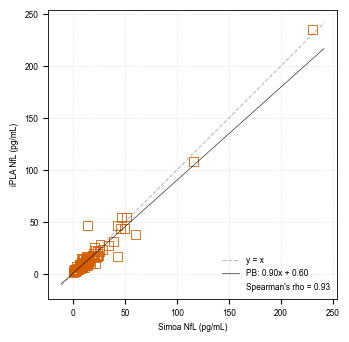

In [11]:

# ── Passing-Bablok ────────────────────────────────────────────────────────────
beta_edta, alpha_edta = passing_bablok(edta_paired['Simoa NfL pg/ml'], edta_paired['PLA NfL pg/ml'])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

ax.scatter(
    edta_paired['Simoa NfL pg/ml'], edta_paired['PLA NfL pg/ml'],
    s=40, marker='s',
    facecolors='none', edgecolors=matrix_colours['EDTA plasma'],
    linewidths=0.6, zorder=3
)

ax.set_xlabel('Simoa NfL (pg/mL)')
ax.set_ylabel('iPLA NfL (pg/mL)')
ax.set_aspect('equal', adjustable='box')

x_range = np.linspace(*ax.get_xlim(), 200)
ax.plot(x_range, x_range,
        color='#BBBBBB', linewidth=0.8, ls='--', zorder=1)
ax.plot(x_range, beta_edta[0] * x_range + alpha_edta[0],
        color=okabe_ito['black'], linewidth=0.4, zorder=4)

Rs, _ = spearmanr(edta_paired['Simoa NfL pg/ml'], edta_paired['PLA NfL pg/ml'],
                  nan_policy='omit')

stats_handles = [
    Line2D([0], [0], color='#BBBBBB', ls='--', linewidth=0.8, label='y = x'),
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.4,
           label=f'PB: {beta_edta[0]:.2f}x + {alpha_edta[0]:.2f}'),
    Line2D([0], [0], color='none', label=f"Spearman's rho = {Rs:.2f}"),
]
ax.legend(handles=stats_handles, frameon=False, loc='lower right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('SimoavPLA_Beyond_MiND_EDTA_full.svg', dpi=300, bbox_inches='tight')
plt.show()

Use this one in main (best visual distribution)

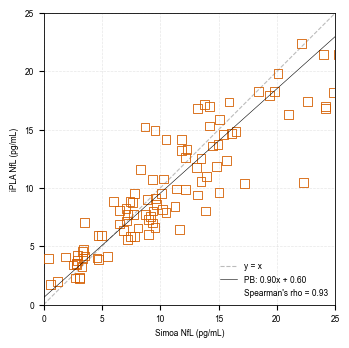

In [12]:
# ── Beyond + MiND EDTA: Passing-Bablok (main figure, axis limited to 25 pg/mL) ──
# PB regression fitted on full range — axis range reflects cohort distribution

beta_edta, alpha_edta = passing_bablok(edta_paired['Simoa NfL pg/ml'], edta_paired['PLA NfL pg/ml'])

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

ax.scatter(
    edta_paired['Simoa NfL pg/ml'], edta_paired['PLA NfL pg/ml'],
    s=40, marker='s',
    facecolors='none', edgecolors=matrix_colours['EDTA plasma'],
    linewidths=0.6, zorder=3
)

ax.set_xlabel('Simoa NfL (pg/mL)')
ax.set_ylabel('iPLA NfL (pg/mL)')
ax.set_xlim(0, 25)
ax.set_ylim(0, 25)
ax.set_aspect('equal', adjustable='box')

x_range = np.linspace(0, 25, 200)
ax.plot(x_range, x_range,
        color='#BBBBBB', linewidth=0.8, ls='--', zorder=1)
ax.plot(x_range, beta_edta[0] * x_range + alpha_edta[0],
        color=okabe_ito['black'], linewidth=0.4, zorder=4)

Rs, _ = spearmanr(edta_paired['Simoa NfL pg/ml'], edta_paired['PLA NfL pg/ml'],
                  nan_policy='omit')

stats_handles = [
    Line2D([0], [0], color='#BBBBBB', ls='--', linewidth=0.8, label='y = x'),
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.4,
           label=f'PB: {beta_edta[0]:.2f}x + {alpha_edta[0]:.2f}'),
    Line2D([0], [0], color='none', label=f"Spearman's rho = {Rs:.2f}"),
]
ax.legend(handles=stats_handles, frameon=False, loc='lower right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('SimoavPLA_Beyond_MiND_EDTA_main.svg', dpi=300, bbox_inches='tight')
plt.show()

BeYOND + MiND EDTA Sample, <200pg/ml  
Separate PB testing for bias at low concentrations

EDTA combined <200 pg/mL N = 113


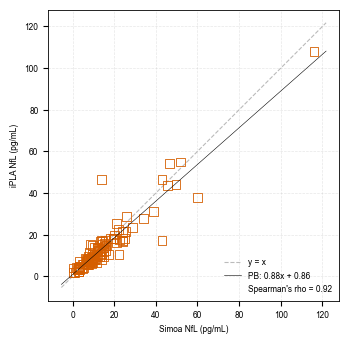

In [13]:
# ── Beyond + MiND EDTA <200 pg/mL: Passing-Bablok ────────────────────────────

edta_paired_200 = edta_paired[edta_paired['Simoa NfL pg/ml'] < 200].reset_index(drop=True)
print(f"EDTA combined <200 pg/mL N = {len(edta_paired_200)}")

beta_edta_200, alpha_edta_200 = passing_bablok(edta_paired_200['Simoa NfL pg/ml'], edta_paired_200['PLA NfL pg/ml'])

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

ax.scatter(
    edta_paired_200['Simoa NfL pg/ml'], edta_paired_200['PLA NfL pg/ml'],
    s=40, marker='s',
    facecolors='none', edgecolors=matrix_colours['EDTA plasma'],
    linewidths=0.6, zorder=3
)

ax.set_xlabel('Simoa NfL (pg/mL)')
ax.set_ylabel('iPLA NfL (pg/mL)')
ax.set_aspect('equal', adjustable='box')

x_range = np.linspace(*ax.get_xlim(), 200)
ax.plot(x_range, x_range,
        color='#BBBBBB', linewidth=0.8, ls='--', zorder=1)
ax.plot(x_range, beta_edta_200[0] * x_range + alpha_edta_200[0],
        color=okabe_ito['black'], linewidth=0.4, zorder=4)

Rs, _ = spearmanr(edta_paired_200['Simoa NfL pg/ml'], edta_paired_200['PLA NfL pg/ml'],
                  nan_policy='omit')

stats_handles = [
    Line2D([0], [0], color='#BBBBBB', ls='--', linewidth=0.8, label='y = x'),
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.4,
           label=f'PB: {beta_edta_200[0]:.2f}x + {alpha_edta_200[0]:.2f}'),
    Line2D([0], [0], color='none', label=f"Spearman's rho = {Rs:.2f}"),
]
ax.legend(handles=stats_handles, frameon=False, loc='lower right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('SimoavPLA_Beyond_MiND_EDTA_200.svg', dpi=300, bbox_inches='tight')
plt.show()

BeYOND + MiND EDTA Sample, <25pg/ml  
Separate PB testing for bias at low concentrations

EDTA combined <25 pg/mL N = 100


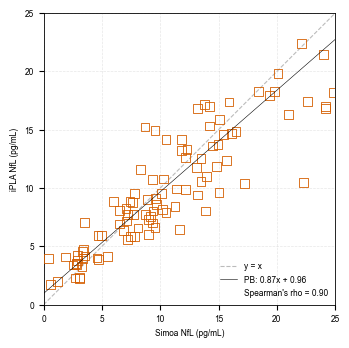

In [14]:
# ── Beyond + MiND EDTA <25 pg/mL: Passing-Bablok ─────────────────────────────

edta_paired_25 = edta_paired[edta_paired['Simoa NfL pg/ml'] < 25].reset_index(drop=True)
print(f"EDTA combined <25 pg/mL N = {len(edta_paired_25)}")

beta_edta_25, alpha_edta_25 = passing_bablok(edta_paired_25['Simoa NfL pg/ml'], edta_paired_25['PLA NfL pg/ml'])

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

ax.scatter(
    edta_paired_25['Simoa NfL pg/ml'], edta_paired_25['PLA NfL pg/ml'],
    s=40, marker='s',
    facecolors='none', edgecolors=matrix_colours['EDTA plasma'],
    linewidths=0.6, zorder=3
)

ax.set_xlabel('Simoa NfL (pg/mL)')
ax.set_ylabel('iPLA NfL (pg/mL)')
ax.set_xlim(0, 25)
ax.set_ylim(0, 25)
ax.set_aspect('equal', adjustable='box')

x_range = np.linspace(0, 25, 200)
ax.plot(x_range, x_range,
        color='#BBBBBB', linewidth=0.8, ls='--', zorder=1)
ax.plot(x_range, beta_edta_25[0] * x_range + alpha_edta_25[0],
        color=okabe_ito['black'], linewidth=0.4, zorder=4)

Rs, _ = spearmanr(edta_paired_25['Simoa NfL pg/ml'], edta_paired_25['PLA NfL pg/ml'],
                  nan_policy='omit')

stats_handles = [
    Line2D([0], [0], color='#BBBBBB', ls='--', linewidth=0.8, label='y = x'),
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.4,
           label=f'PB: {beta_edta_25[0]:.2f}x + {alpha_edta_25[0]:.2f}'),
    Line2D([0], [0], color='none', label=f"Spearman's rho = {Rs:.2f}"),
]
ax.legend(handles=stats_handles, frameon=False, loc='lower right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('SimoavPLA_Beyond_MiND_EDTA_25.svg', dpi=300, bbox_inches='tight')
plt.show()

## Bland-Altman analysis

Log-transformed Bland-Altman plots (log10 ratio vs log10 geometric mean) provided as supplementary figures. The log transformation is appropriate given the wide concentration range. PB regression is the primary method comparison statistic reported in the main text.


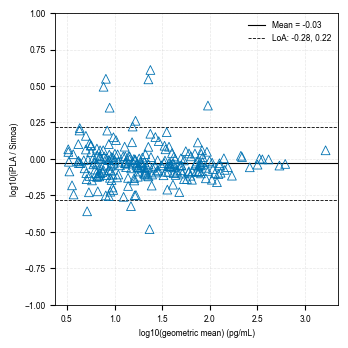

In [15]:
# ── Bland-Altman: RMH Li-Hep (supplementary, full range) ─────────────────────

mask = (rmh_paired['Simoa NfL pg/ml'] > 0) & (rmh_paired['PLA NfL pg/ml'] > 0)
x_log = np.log10(rmh_paired.loc[mask, 'Simoa NfL pg/ml'])
y_log = np.log10(rmh_paired.loc[mask, 'PLA NfL pg/ml'])

log_mean = (x_log + y_log) / 2
log_diff = y_log - x_log

mean_diff = np.mean(log_diff)
sd_diff   = np.std(log_diff, ddof=1)
upper_loa = mean_diff + 1.96 * sd_diff
lower_loa = mean_diff - 1.96 * sd_diff

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

ax.scatter(log_mean, log_diff,
           s=40, marker='^',
           facecolors='none', edgecolors=matrix_colours['Li-Hep plasma'],
           linewidths=0.6, zorder=3)

ax.axhline(mean_diff, color=okabe_ito['black'], linewidth=0.8, zorder=2)
ax.axhline(upper_loa, color=okabe_ito['black'], linewidth=0.6, ls='--', zorder=2)
ax.axhline(lower_loa, color=okabe_ito['black'], linewidth=0.6, ls='--', zorder=2)

ax.set_xlabel('log10(geometric mean) (pg/mL)')
ax.set_ylabel('log10(iPLA / Simoa)')
ax.set_ylim(-1, 1)

stats_handles = [
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.8,
           label=f'Mean = {mean_diff:.2f}'),
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.6, ls='--',
           label=f'LoA: {lower_loa:.2f}, {upper_loa:.2f}'),
]
ax.legend(handles=stats_handles, frameon=False, loc='upper right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
# plt.savefig('BA_RMH_LH_supp.svg', dpi=300, bbox_inches='tight')
plt.show()

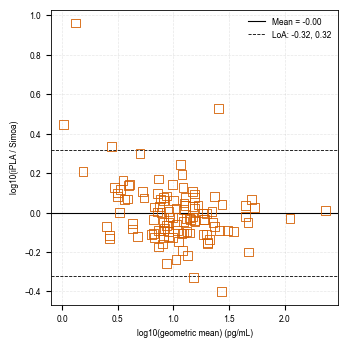

In [16]:
# ── Bland-Altman: Beyond + MiND EDTA (supplementary, full range) ─────────────

mask = (edta_paired['Simoa NfL pg/ml'] > 0) & (edta_paired['PLA NfL pg/ml'] > 0)
x_log = np.log10(edta_paired.loc[mask, 'Simoa NfL pg/ml'])
y_log = np.log10(edta_paired.loc[mask, 'PLA NfL pg/ml'])

log_mean = (x_log + y_log) / 2
log_diff = y_log - x_log

mean_diff  = np.mean(log_diff)
sd_diff    = np.std(log_diff, ddof=1)
upper_loa  = mean_diff + 1.96 * sd_diff
lower_loa  = mean_diff - 1.96 * sd_diff

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

ax.scatter(log_mean, log_diff,
           s=40, marker='s',
           facecolors='none', edgecolors=matrix_colours['EDTA plasma'],
           linewidths=0.6, zorder=3)

ax.axhline(mean_diff, color=okabe_ito['black'],    linewidth=0.8, zorder=2)
ax.axhline(upper_loa, color=okabe_ito['black'],    linewidth=0.6, ls='--', zorder=2)
ax.axhline(lower_loa, color=okabe_ito['black'],    linewidth=0.6, ls='--', zorder=2)

ax.set_xlabel('log10(geometric mean) (pg/mL)')
ax.set_ylabel('log10(iPLA / Simoa)')

stats_handles = [
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.8,
           label=f'Mean = {mean_diff:.2f}'),
    Line2D([0], [0], color=okabe_ito['black'], linewidth=0.6, ls='--',
           label=f'LoA: {lower_loa:.2f}, {upper_loa:.2f}'),
]
ax.legend(handles=stats_handles, frameon=False, loc='upper right')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
# plt.savefig('BA_Beyond_MiND_EDTA_supp.svg', dpi=300, bbox_inches='tight')
plt.show()

## Lin's Concordance Correlation Coefficient (CCC)

CCC combines Pearson's correlation with a penalty for systematic bias from the line of perfect concordance (y = x). Computed using `torchmetrics` (PyTorch backend). Full-range values reported for each cohort.


In [ ]:
# ── Lin's Concordance Correlation Coefficient ─────────────────────────────────

from torchmetrics.functional.regression import concordance_corrcoef
import torch

def compute_ccc(x, y, label):
    preds  = torch.tensor(y.values, dtype=torch.float32)
    target = torch.tensor(x.values, dtype=torch.float32)
    if torch.cuda.is_available():
        preds  = preds.to('cuda')
        target = target.to('cuda')
    ccc = concordance_corrcoef(preds, target)
    print(f"{label}: CCC = {ccc.cpu().item():.4f}")

compute_ccc(rmh_paired['Simoa NfL pg/ml'],  rmh_paired['PLA NfL pg/ml'],  'RMH Li-Hep')
compute_ccc(edta_paired['Simoa NfL pg/ml'], edta_paired['PLA NfL pg/ml'], 'Beyond + MiND EDTA')